<a href="https://colab.research.google.com/github/LisethTiria/Biosenales-2025-1/blob/main/Proyecto3_ecg/proyecto3_ecg.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<div style="display: flex; align-items: center; gap: 20px; background-color: rgba(9, 169, 36, 0.72); padding: 20px; border-radius: 10px; color: white;">
  <img src="https://github.com/LisethTiria/Biosenales-2025-1/blob/main/Proyecto3_ecg/logo_udea.png?raw=1" alt="Logo UdeA" style="height: 80px;">
  <div>
    <h1 style="margin: 0; font-size: 2em;">Proyecto 3 - Filtrado de señales ECG</h1>
    <p style="margin: 2px 0 0 0; font-size: 1.3em;"><strong>Bioseñales y Sistemas</strong></p>
    <p style="margin: 10px 0 0 0; font-size: 1.2em;">Universidad de Antioquia - Facultad de Ingeniería</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Integrantes: Luisa Taho, Liseth Tiria, Victor Ocampo</p>
    <p style="margin: 5px 0 0 0; font-size: 1em;">Profesores: John Fredy Ochoa, Juliana Moreno Rada</p>
  </div>
</div>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.signal as signal
from scipy import fft
from scipy.fftpack import dct
import matplotlib.pyplot as plt;
import scipy.io as sio;
import seaborn as sns
from scipy.signal import detrend
from scipy.signal.windows import hamming
from scipy.stats import kstest, zscore, kruskal
from scipy.stats import ttest_ind, shapiro, levene, mannwhitneyu
from scipy import stats
import os
import librosa
import zipfile
from scipy.signal import welch

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
# Carga el archivo 'Diagnostics.xlsx' desde Google Drive
diag = pd.read_excel('/content/drive/MyDrive/Colab Notebooks/Biosenales/Diagnostics.xlsx')

diag

,FileName,Rhythm,Beat,PatientAge,Gender,VentricularRate,AtrialRate,QRSDuration,QTInterval,QTCorrected,RAxis,TAxis,QRSCount,QOnset,QOffset,TOffset
0,MUSE_20180113_171327_27000,AFIB,RBBB TWC,85,MALE,117,234,114,356,496,81,-27,19,208,265,386
1,MUSE_20180112_073319_29000,SB,TWC,59,FEMALE,52,52,92,432,401,76,42,8,215,261,431
2,MUSE_20180111_165520_97000,SA,NONE,20,FEMALE,67,67,82,382,403,88,20,11,224,265,415
3,MUSE_20180113_121940_44000,SB,NONE,66,MALE,53,53,96,456,427,34,3,9,219,267,447
4,MUSE_20180112_122850_57000,AF,STDD STTC,73,FEMALE,162,162,114,252,413,68,-40,26,228,285,354
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10641,MUSE_20181222_204306_99000,SVT,NONE,80,FEMALE,196,73,168,284,513,258,244,32,177,261,319
10642,MUSE_20181222_204309_22000,SVT,NONE,81,FEMALE,162,81,162,294,482,110,-75,27,173,254,320
10643,MUSE_20181222_204310_31000,SVT,NONE,39,MALE,152,92,152,340,540,250,38,25,208,284,378
10644,MUSE_20181222_204312_58000,SVT,NONE,76,MALE,175,178,128,310,529,98,-83,29,205,269,360


In [6]:
# Filtrar primero en diag
afib_data = diag[(diag['Rhythm'] == 'AFIB')]
afib_archivos = [f + '.csv' for f in afib_data['FileName'].tolist()]

sb_data = diag[(diag['Rhythm'] == 'SB')]
sb_archivos = [f + '.csv' for f in sb_data['FileName'].tolist()]

sr_data = diag[(diag['Rhythm'] == 'SR')]
sr_archivos = [f + '.csv' for f in sr_data['FileName'].tolist()]

In [10]:
import os
import zipfile

# Crear carpetas de destino
base_extract_dir = '/content/'
sb_extract_dir = os.path.join(base_extract_dir, 'sb_data')
afib_extract_dir = os.path.join(base_extract_dir, 'afib_data')
sr_extract_dir = os.path.join(base_extract_dir, 'sr_data')
os.makedirs(sb_extract_dir, exist_ok=True)
os.makedirs(afib_extract_dir, exist_ok=True)
k = os.makedirs(sr_extract_dir, exist_ok=True)

# Ruta al archivo ZIP
zip_filepath = '/content/drive/MyDrive/Colab Notebooks/Biosenales/ECGData.zip'

# Mapeo de archivos deseados y sus carpetas
desired_files = {name: sb_extract_dir for name in sb_archivos}
desired_files.update({name: afib_extract_dir for name in afib_archivos})
desired_files.update({name: sr_extract_dir for name in sr_archivos})

# Extraer los archivos desde el ZIP
with zipfile.ZipFile(zip_filepath, 'r') as zip_ref:
    for zip_info in zip_ref.infolist():
        filename = os.path.basename(zip_info.filename)
        if filename in desired_files:
            with zip_ref.open(zip_info) as source_file:
                output_path = os.path.join(desired_files[filename], filename)
                with open(output_path, 'wb') as out_file:
                    out_file.write(source_file.read())
            #rint(f"Archivo '{filename}' extraído a '{desired_files[filename]}'")
print(f"Cantidad de archivos para SB (bradicardia sinusal): {len(sb_data)}")
print(f"Cantidad de archivos para AFIB (fibrilación auricular): {len(afib_data)}")
print(f"Cantidad de archivos para SR (ritmo sinusal): {len(sr_data)}")


Cantidad de archivos para SB (bradicardia sinusal): 3889
Cantidad de archivos para AFIB (fibrilación auricular): 1780
Cantidad de archivos para SR (ritmo sinusal): 1826


# Seleccionar 10 señales aleatorias

In [23]:
import random
import pandas as pd
import os

# Ruta para guardar la lista persistente de señales
selected_files_path = '/content/selected_signals.txt'

# Combinar todas las señales disponibles
all_signals = sb_archivos + afib_archivos + sr_archivos

# Verificar si ya hay un archivo con señales seleccionadas
if os.path.exists(selected_files_path):
    with open(selected_files_path, 'r') as f:
        selected_files = [line.strip() for line in f.readlines()]
else:
    selected_files = random.sample(all_signals, 10)
    with open(selected_files_path, 'w') as f:
        f.writelines(f"{name}\n" for name in selected_files)

# Cargar las señales seleccionadas
selected_signals = []
for file in selected_files:
    if file in sb_archivos:
        path = os.path.join(sb_extract_dir, file)
    elif file in afib_archivos:
        path = os.path.join(afib_extract_dir, file)
    elif file in sr_archivos:
        path = os.path.join(sr_extract_dir, file)
    else:
        continue

    # Leer el archivo CSV con encabezados
    df = pd.read_csv(path, sep=None, engine='python')  # Auto detecta el separador
    if "II" not in df.columns:
        raise ValueError(f'El archivo {file} no contiene la columna "II"')

    signal = df["II"]  # Extraer solo la derivación II
    selected_signals.append(signal)


In [95]:
def wavelet_filter_ecg(signal, wavelet, level):


    # Función para estimar el ruido por nivel
    def wnoisest(coeff):
        stdc = np.zeros((len(coeff), 1))
        for i in range(len(coeff)):
            stdc[i] = np.median(np.abs(coeff[i])) / 0.6745
        return stdc

    # Cálculo del umbral global
    def threshold(coeff):
        num_samples = sum(c.shape[0] for c in coeff)
        return np.sqrt(2 * np.log(num_samples))

    # Umbralización suave de los coeficientes
    def wthresh(coeff):
        stds = wnoisest(coeff)
        thr = threshold(coeff)
        filtered = []

        for i, c in enumerate(coeff):
            # Umbralización suave: reduce el valor absoluto
            filtered.append(pywt.threshold(c, value=thr * stds[i], mode='soft'))
        return filtered

    # Descomposición
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    approx = coeffs[0]
    details = coeffs[1:]

    # Umbralización en los detalles
    details_thresh = wthresh(details)

    # Reconstrucción
    coeffs_filt = [approx] + details_thresh
    signal_rec = pywt.waverec(coeffs_filt, wavelet)

    # Ajuste de longitud por padding
    return signal_rec[:len(signal)]

In [91]:
from scipy.signal import iirfilter, filtfilt

def filtro_pasa_altas_ecg(signal, fs, cutoff=0.5, order=4):
    nyquist = fs / 2
    b, a = iirfilter(order, cutoff / nyquist, btype='highpass', analog=False)
    return filtfilt(b, a, signal)

def filtro_pasa_bajas_ecg(signal, fs, cutoff=50, order=3):
    nyquist = fs / 2
    b, a = iirfilter(order, cutoff / nyquist, btype='lowpass', analog=False)
    return filtfilt(b, a, signal)


# Flujo 1
*   Filtro pasa-altas IIR a 0.5 Hz
*   Filtro wavelet modificado
*   FIltro pasabajas 50 Hz




In [131]:
import numpy as np
import scipy.signal as signal
import pywt
import matplotlib.pyplot as plt

fs = 500  # frecuencia de muestreo
filtered_signals_f1 = []

for idx, sig in enumerate(selected_signals):
    # 1. Filtro pasaaltas IIR (0.5 Hz)
    sig_hp = filtro_pasa_altas_ecg(sig, fs)


    # 2. Filtro wavelet adaptado a ECG
    sig_wav = wavelet_filter_ecg(sig_hp, wavelet='db4', level=5)


    # 3. Filtro pasabajas IIR (50 Hz)
    sig_lp = filtro_pasa_bajas_ecg(sig_wav, fs)


    filtered_signals_f1.append(sig_lp)


# Flujo 2
*   Detrend
*   Filtro wavelet modificado
*   FIltro pasabajas IIR 50 Hz

In [122]:
filtered_signals_f2 = []

for idx, sig in enumerate(selected_signals):
    # 1. Detrend
    sig_detrend = signal.detrend(sig)

    # 2. Filtro wavelet
    sig_wav = wavelet_filter_ecg(sig_detrend, wavelet='db4', level=5)
    # 3. Filtro pasabajas IIR (50 Hz)
    sig_lp = filtro_pasa_bajas_ecg(sig_wav, fs)


    filtered_signals_f2.append(sig_lp)


# Flujo 3
*   Filtro pasabajas IIR 50 Hz
*   Filtro LOESS
*   Filtro NLM


Dado que los filtros LOESS y NLM no están incluidos en scipy se usará:
*   `statsmodels` para LOESS

*   `skimage.restoration.denoise_nl_means` para NLM

In [30]:
!pip install statsmodels scikit-image


In [134]:
from statsmodels.nonparametric.smoothers_lowess import lowess
from skimage.restoration import denoise_nl_means

filtered_signals_f3 = []

for sig in selected_signals:
    # 1. Filtro pasabajas
    sig_lp = filtro_pasa_bajas_ecg(sig, fs)

    # 2. LOESS
    loess_result = lowess(sig_lp, np.arange(len(sig_lp)), frac=0.01, return_sorted=False)

    # 3. NLM adaptado
    sig_2d = loess_result.reshape(1, -1)
    sigma_est = np.std(loess_result)
    sig_nlm_2d = denoise_nl_means(
        sig_2d,
        h=0.5 * sigma_est,
        fast_mode=True,
        patch_size=5,
        patch_distance=6,
        channel_axis=None
    )
    sig_nlm = sig_nlm_2d.flatten() # Flatten to 1D

    filtered_signals_f3.append(sig_nlm)

# Comparación visual de los flujos realizados

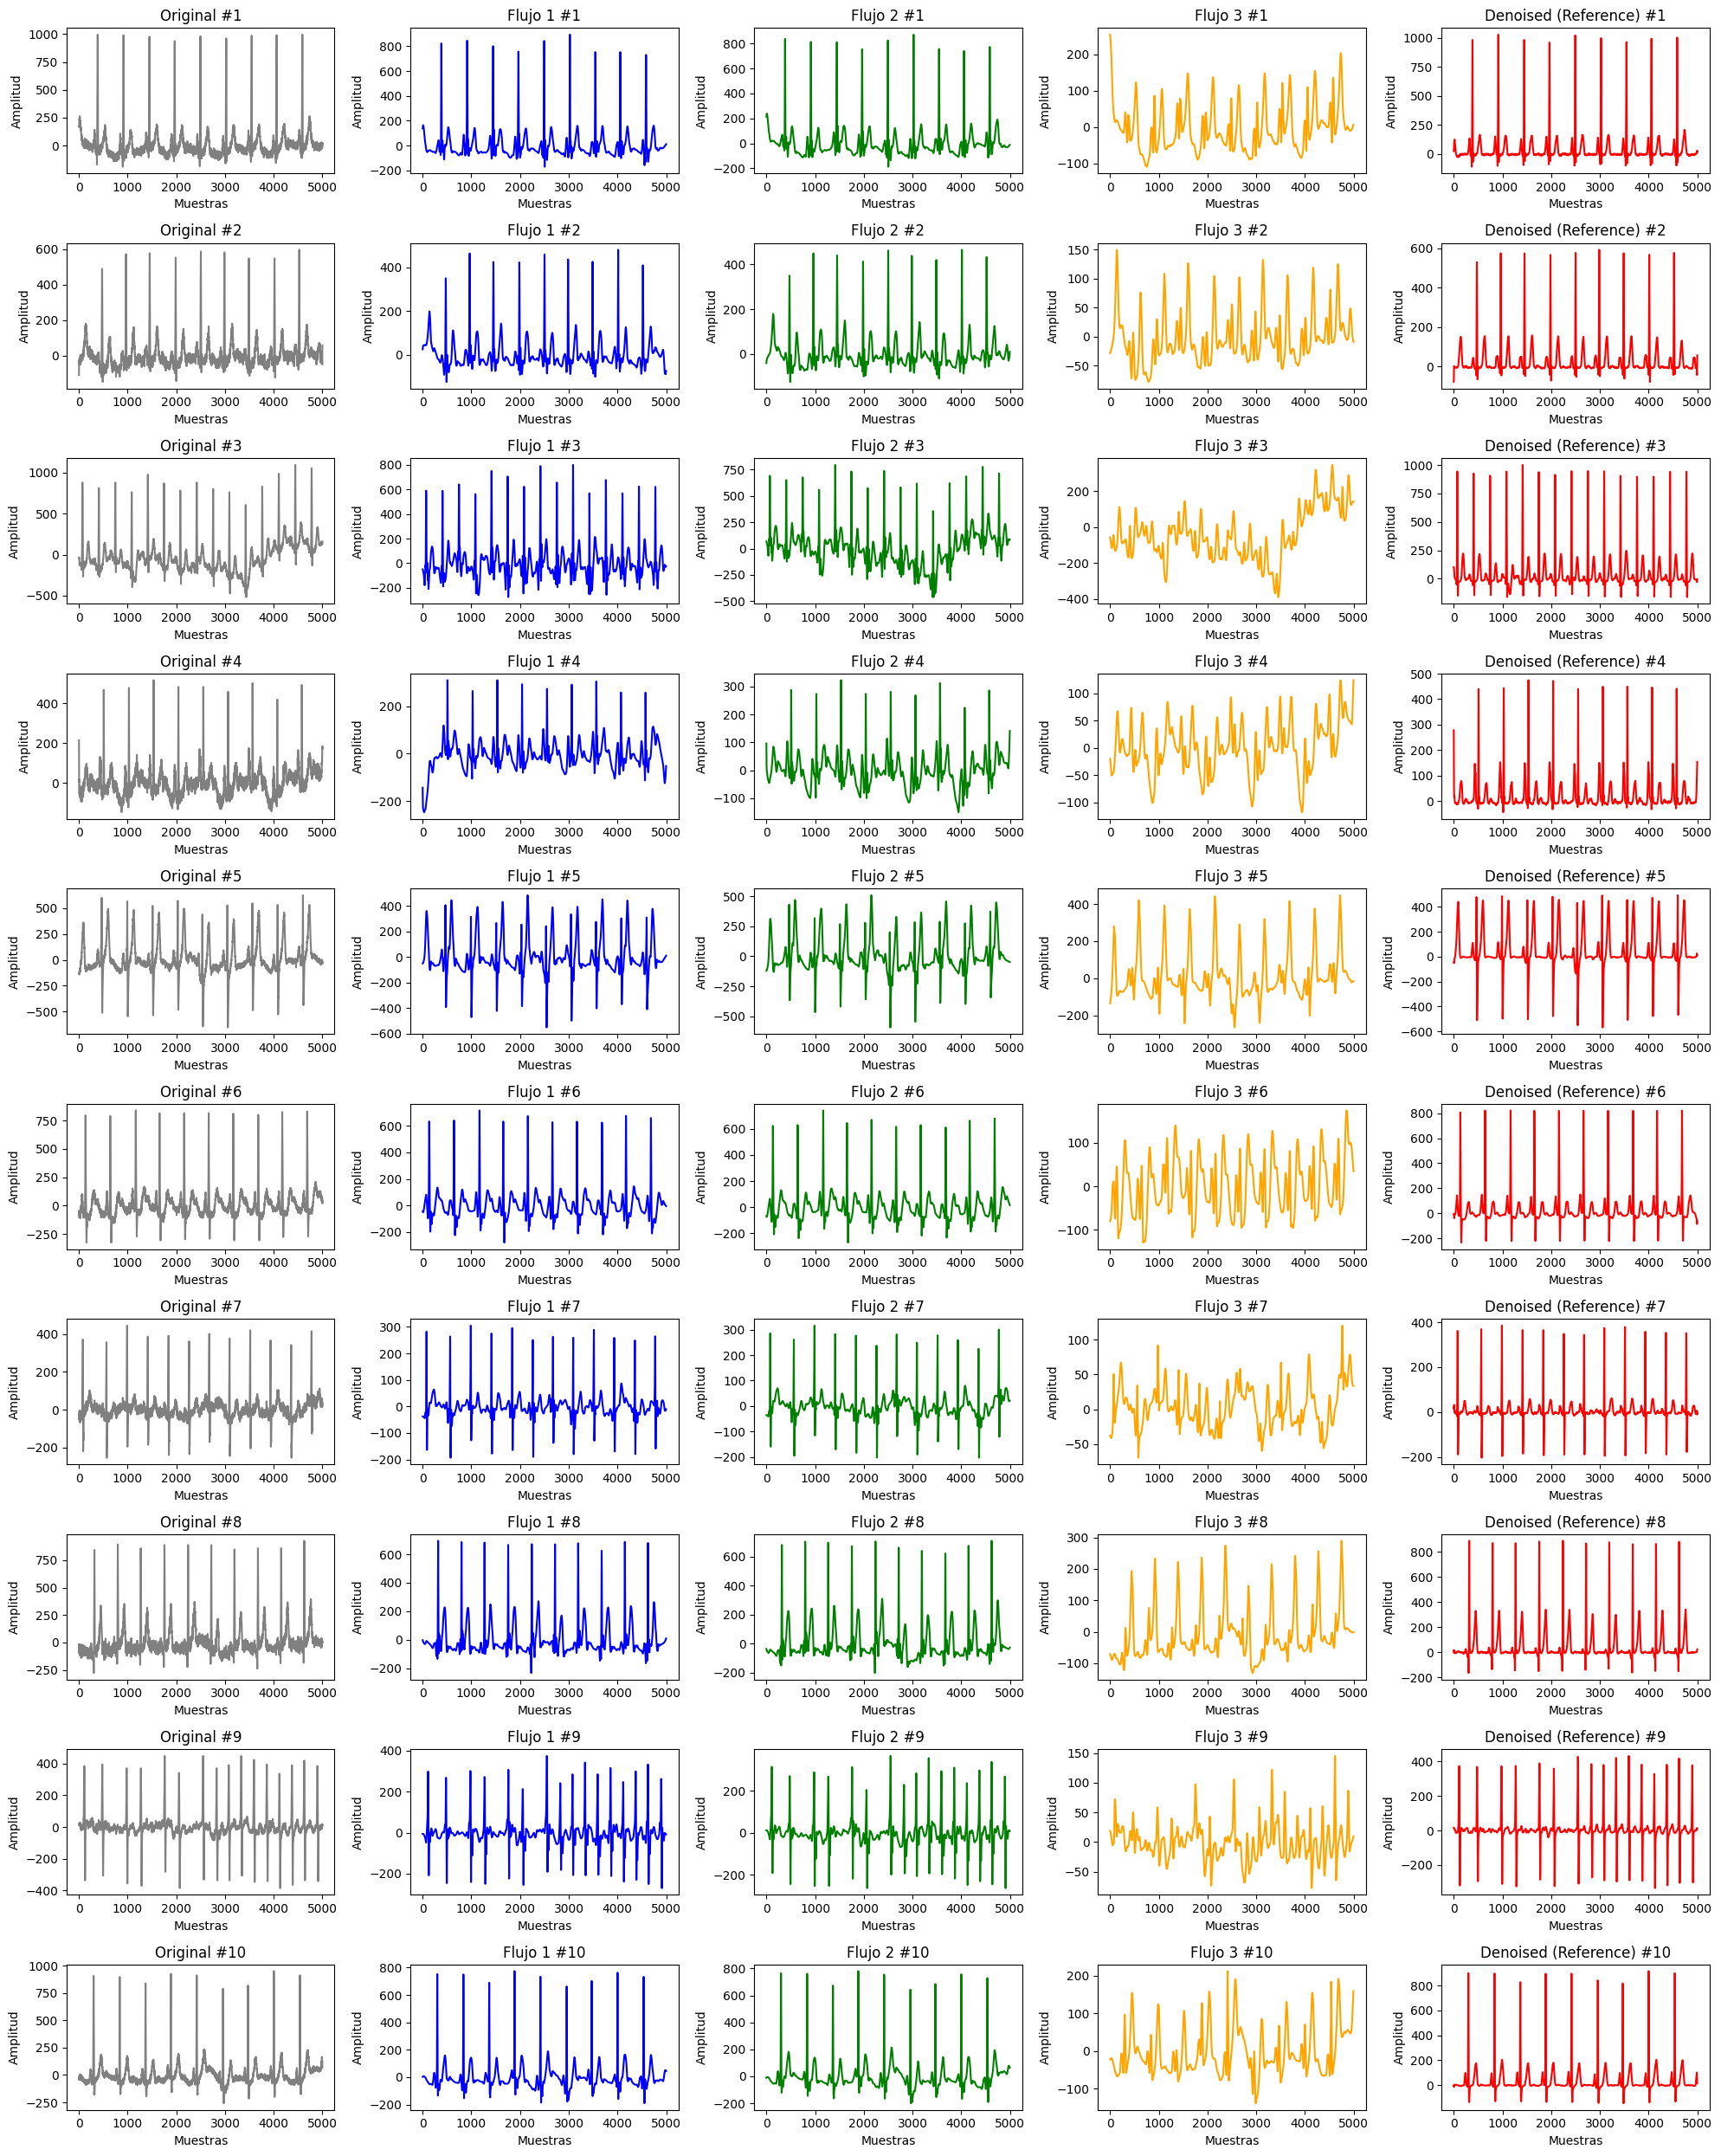

In [135]:
def plot_comparisons(originals, f1, f2, f3, denoised, title_prefix=''):
    num = len(originals)
    plt.figure(figsize=(20, num * 2.5)) # Increased figure width for the extra plot

    for i in range(num):
        plt.subplot(num, 5, i * 5 + 1) # 5 columns for original, 3 flows, and denoised
        plt.plot(originals[i], color='gray')
        plt.title(f'{title_prefix}Original #{i+1}')
        plt.xlabel('Muestras')
        plt.ylabel('Amplitud')

        plt.subplot(num, 5, i * 5 + 2)
        plt.plot(f1[i], color='blue')
        plt.title(f'{title_prefix}Flujo 1 #{i+1}')
        plt.xlabel('Muestras')
        plt.ylabel('Amplitud')

        plt.subplot(num, 5, i * 5 + 3)
        plt.plot(f2[i], color='green')
        plt.title(f'{title_prefix}Flujo 2 #{i+1}')
        plt.xlabel('Muestras')
        plt.ylabel('Amplitud')


        plt.subplot(num, 5, i * 5 + 4)
        plt.plot(f3[i], color='orange')
        plt.title(f'{title_prefix}Flujo 3 #{i+1}')
        plt.xlabel('Muestras')
        plt.ylabel('Amplitud')

        plt.subplot(num, 5, i * 5 + 5) # New subplot for denoised signals
        plt.plot(denoised[i], color='red')
        plt.title(f'{title_prefix}Denoised (Reference) #{i+1}')
        plt.xlabel('Muestras')
        plt.ylabel('Amplitud')


    plt.tight_layout()
    plt.show()

# Llamar función para mostrar comparaciones
plot_comparisons(selected_signals, filtered_signals_f1, filtered_signals_f2, filtered_signals_f3, denoised_signals)

In [136]:
import os
import zipfile

# Define the path to the denoised zip file
denoised_zip_filepath = '/content/drive/MyDrive/Colab Notebooks/Biosenales/ECGDataDenoised.zip'

# Create a temporary directory to extract the denoised files into
denoised_extract_dir = '/content/denoised_data'
os.makedirs(denoised_extract_dir, exist_ok=True)

# Extract the desired files from the denoised ZIP
with zipfile.ZipFile(denoised_zip_filepath, 'r') as zip_ref:
    for zip_info in zip_ref.infolist():
        filename = os.path.basename(zip_info.filename)
        if filename in selected_files:
            with zip_ref.open(zip_info) as source_file:
                output_path = os.path.join(denoised_extract_dir, filename)
                with open(output_path, 'wb') as out_file:
                    out_file.write(source_file.read())

In [137]:
def load_denoised_signal(directory, filename, columns):
    """
    Loads the 'II' derivation from a CSV file.
    """
    filepath = os.path.join(directory, filename)
    try:
        # Assuming the denoised files also have the same column structure and are comma-separated
        df = pd.read_csv(filepath, delimiter=',', names=columns)
        if "II" not in df.columns:
            raise ValueError(f'El archivo {filename} no contiene la columna "II"')
        signal = df["II"]
        return signal
    except FileNotFoundError:
        print(f'El archivo {filename} no se encontró en {directory}.')
        return None
    except Exception as e:
        print(f'Error al leer el archivo {filename}: {e}')
        return None

# Define the columns based on the original data structure
columns = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

# Load the denoised signals for the selected files
denoised_signals = []
for filename in selected_files:
    signal = load_denoised_signal(denoised_extract_dir, filename, columns)
    if signal is not None:
        denoised_signals.append(signal)

print(f"Se cargaron {len(denoised_signals)} señales denoised.")

Se cargaron 10 señales denoised.


# Task
Apply the filtering flow 1 (high-pass, wavelet, low-pass) to all 'II' derivation ECG signals from the 'AFIB', 'SB', and 'SR' rhythm categories located in the directories 'afib_data', 'sb_data', and 'sr_data' respectively.

## Load all signals

### Subtask:
Load all the ECG signals from the 'sb_data', 'afib_data', and 'sr_data' directories into separate lists or data structures, making sure to only load the 'II' derivation.


**Reasoning**:
Initialize empty lists and define column names, then load the 'II' derivation for SB signals.



In [138]:
all_sb_signals = []
all_afib_signals = []
all_sr_signals = []

columns = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

for filename in sb_archivos:
    filepath = os.path.join(sb_extract_dir, filename)
    df = pd.read_csv(filepath, delimiter=',', names=columns)
    all_sb_signals.append(df["II"])

**Reasoning**:
Load the 'II' derivation for AFIB and SR signals into their respective lists.



In [139]:
for filename in afib_archivos:
    filepath = os.path.join(afib_extract_dir, filename)
    df = pd.read_csv(filepath, delimiter=',', names=columns)
    all_afib_signals.append(df["II"])

for filename in sr_archivos:
    filepath = os.path.join(sr_extract_dir, filename)
    df = pd.read_csv(filepath, delimiter=',', names=columns)
    all_sr_signals.append(df["II"])

## Apply filtering flow 1

### Subtask:
Iterate through each signal in the loaded lists and apply the sequence of filters from Flow 1: high-pass, wavelet, and low-pass.


**Reasoning**:
Iterate through each signal list and apply the filter sequence for Flow 1.



In [141]:
filtered_sb_signals_f1 = []
filtered_afib_signals_f1 = []
filtered_sr_signals_f1 = []

fs = 500

columns = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
# Reload the signals, skipping the header row this time
all_sb_signals = []
all_afib_signals = []
all_sr_signals = []

for filename in sb_archivos:
    filepath = os.path.join(sb_extract_dir, filename)
    df = pd.read_csv(filepath, delimiter=',', names=columns, skiprows=1)
    all_sb_signals.append(df["II"].astype(float)) # Convert to float

for filename in afib_archivos:
    filepath = os.path.join(afib_extract_dir, filename)
    df = pd.read_csv(filepath, delimiter=',', names=columns, skiprows=1)
    all_afib_signals.append(df["II"].astype(float)) # Convert to float

for filename in sr_archivos:
    filepath = os.path.join(sr_extract_dir, filename)
    df = pd.read_csv(filepath, delimiter=',', names=columns, skiprows=1)
    all_sr_signals.append(df["II"].astype(float)) # Convert to float

# Apply the filters
for sig in all_sb_signals:
    sig_hp = filtro_pasa_altas_ecg(sig, fs)
    sig_wav = wavelet_filter_ecg(sig_hp, wavelet='db4', level=5)
    sig_lp = filtro_pasa_bajas_ecg(sig_wav, fs)
    filtered_sb_signals_f1.append(sig_lp)

for sig in all_afib_signals:
    sig_hp = filtro_pasa_altas_ecg(sig, fs)
    sig_wav = wavelet_filter_ecg(sig_hp, wavelet='db4', level=5)
    sig_lp = filtro_pasa_bajas_ecg(sig_wav, fs)
    filtered_afib_signals_f1.append(sig_lp)

for sig in all_sr_signals:
    sig_hp = filtro_pasa_altas_ecg(sig, fs)
    sig_wav = wavelet_filter_ecg(sig_hp, wavelet='db4', level=5)
    sig_lp = filtro_pasa_bajas_ecg(sig_wav, fs)
    filtered_sr_signals_f1.append(sig_lp)

## Store filtered signals

### Subtask:
Store the filtered signals, potentially in new directories or a structured data format, keeping track of which original file they came from and their rhythm category (AFIB, SB, SR).


**Reasoning**:
Create directories for storing the filtered signals and iterate through the filtered signals and filenames to save them as CSV files in the respective directories.



In [142]:
# Create directories for filtered signals if they don't exist
filtered_sb_dir_f1 = '/content/sb_data_filtered_f1'
filtered_afib_dir_f1 = '/content/afib_data_filtered_f1'
filtered_sr_dir_f1 = '/content/sr_data_filtered_f1'

os.makedirs(filtered_sb_dir_f1, exist_ok=True)
os.makedirs(filtered_afib_dir_f1, exist_ok=True)
os.makedirs(filtered_sr_dir_f1, exist_ok=True)

# Save filtered SB signals
for filename, signal in zip(sb_archivos, filtered_sb_signals_f1):
    df_filtered = pd.DataFrame({'II': signal})
    output_path = os.path.join(filtered_sb_dir_f1, filename)
    df_filtered.to_csv(output_path, index=False)

# Save filtered AFIB signals
for filename, signal in zip(afib_archivos, filtered_afib_signals_f1):
    df_filtered = pd.DataFrame({'II': signal})
    output_path = os.path.join(filtered_afib_dir_f1, filename)
    df_filtered.to_csv(output_path, index=False)

# Save filtered SR signals
for filename, signal in zip(sr_archivos, filtered_sr_signals_f1):
    df_filtered = pd.DataFrame({'II': signal})
    output_path = os.path.join(filtered_sr_dir_f1, filename)
    df_filtered.to_csv(output_path, index=False)

print(f"Filtered SB signals saved to: {filtered_sb_dir_f1}")
print(f"Filtered AFIB signals saved to: {filtered_afib_dir_f1}")
print(f"Filtered SR signals saved to: {filtered_sr_dir_f1}")

Filtered SB signals saved to: /content/sb_data_filtered_f1
Filtered AFIB signals saved to: /content/afib_data_filtered_f1
Filtered SR signals saved to: /content/sr_data_filtered_f1


## Verify filtered signals

### Subtask:
Optionally, load and plot a few of the filtered signals from each category to visually confirm that the filtering was applied correctly.


**Reasoning**:
Select a few filenames from each rhythm category, load their corresponding filtered signals, and plot them to visually inspect the filtering results.



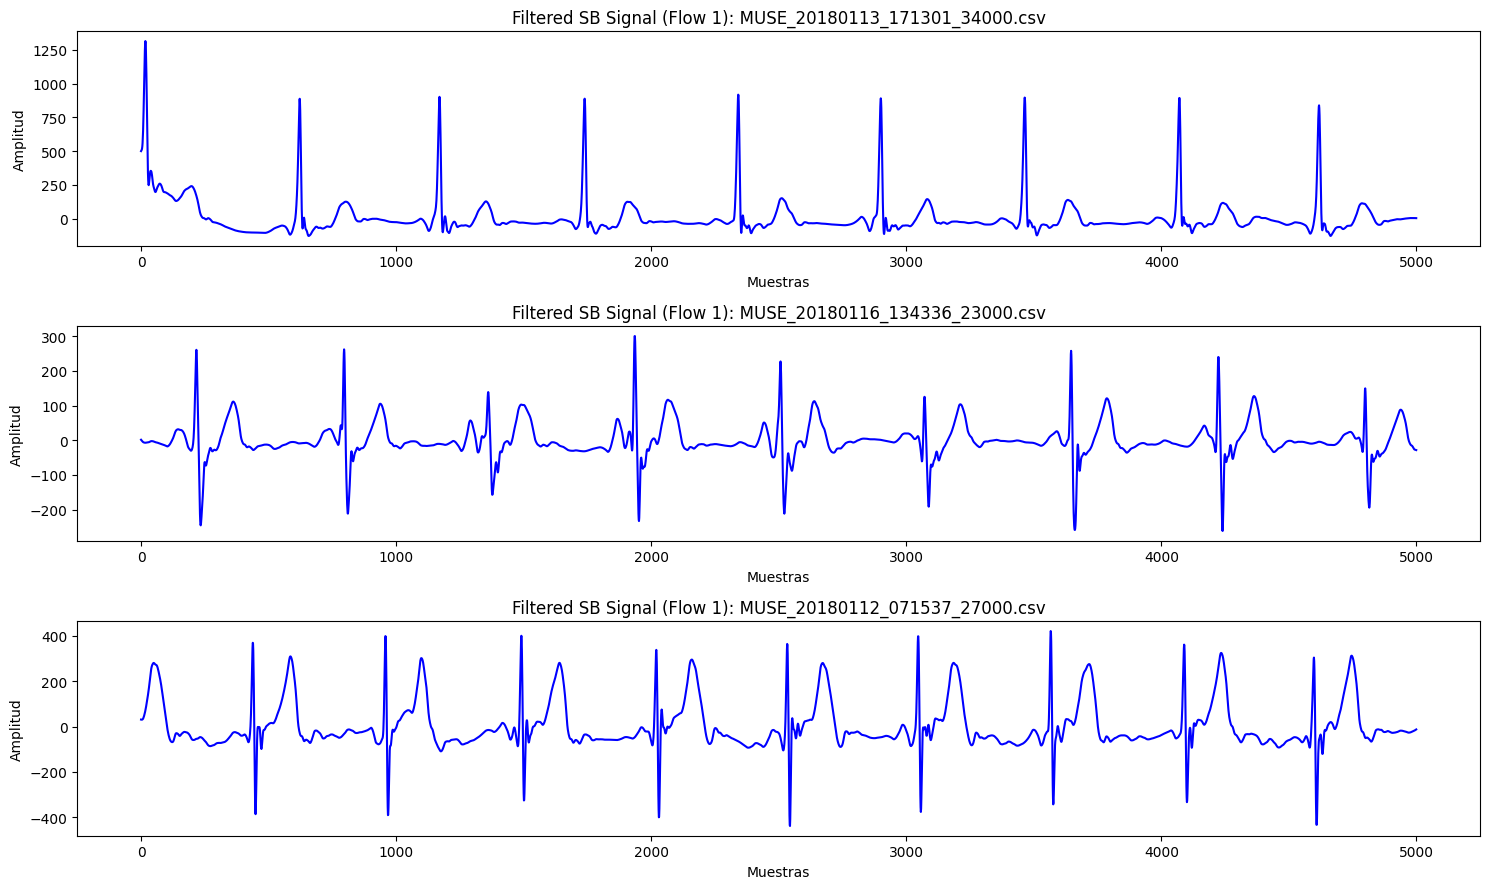

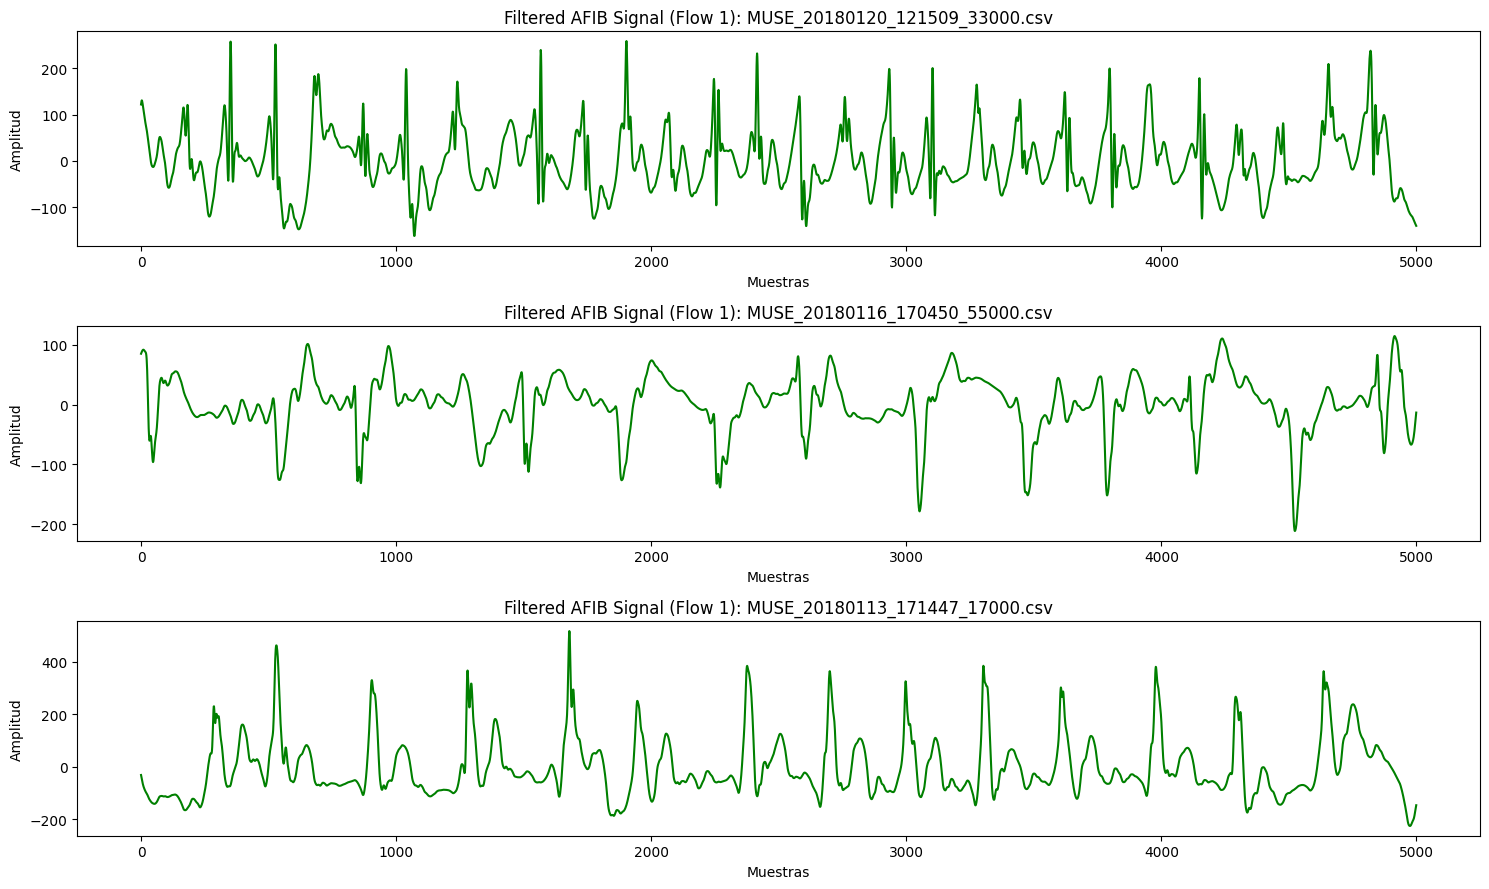

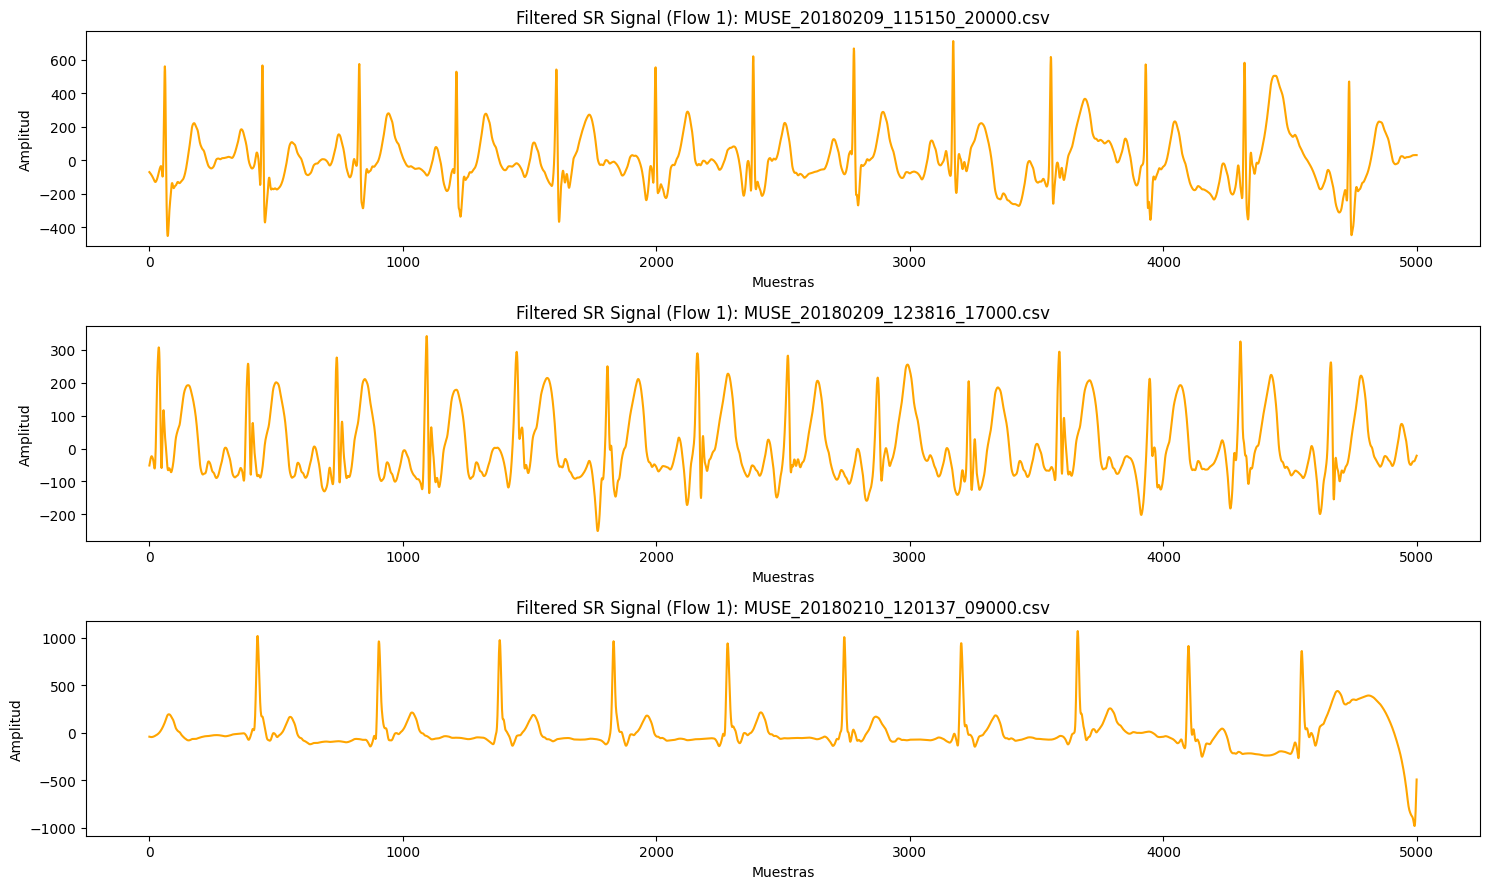

In [143]:
import random
import matplotlib.pyplot as plt
import os
import pandas as pd

# Select a few random files from each category for plotting
num_plots = 3
selected_sb_files_for_plot = random.sample(sb_archivos, min(num_plots, len(sb_archivos)))
selected_afib_files_for_plot = random.sample(afib_archivos, min(num_plots, len(afib_archivos)))
selected_sr_files_for_plot = random.sample(sr_archivos, min(num_plots, len(sr_archivos)))

# Function to load filtered signal from a given directory
def load_filtered_signal(directory, filename):
    filepath = os.path.join(directory, filename)
    try:
        df_filtered = pd.read_csv(filepath)
        # Assuming the filtered file only contains the 'II' column and no index
        return df_filtered['II']
    except FileNotFoundError:
        print(f"Filtered file not found: {filepath}")
        return None
    except Exception as e:
        print(f"Error loading filtered file {filepath}: {e}")
        return None

# Load and plot filtered SB signals
plt.figure(figsize=(15, num_plots * 3))
for i, filename in enumerate(selected_sb_files_for_plot):
    signal = load_filtered_signal(filtered_sb_dir_f1, filename)
    if signal is not None:
        plt.subplot(num_plots, 1, i + 1)
        plt.plot(signal, color='blue')
        plt.title(f'Filtered SB Signal (Flow 1): {filename}')
        plt.xlabel('Muestras')
        plt.ylabel('Amplitud')
plt.tight_layout()
plt.show()

# Load and plot filtered AFIB signals
plt.figure(figsize=(15, num_plots * 3))
for i, filename in enumerate(selected_afib_files_for_plot):
    signal = load_filtered_signal(filtered_afib_dir_f1, filename)
    if signal is not None:
        plt.subplot(num_plots, 1, i + 1)
        plt.plot(signal, color='green')
        plt.title(f'Filtered AFIB Signal (Flow 1): {filename}')
        plt.xlabel('Muestras')
        plt.ylabel('Amplitud')
plt.tight_layout()
plt.show()

# Load and plot filtered SR signals
plt.figure(figsize=(15, num_plots * 3))
for i, filename in enumerate(selected_sr_files_for_plot):
    signal = load_filtered_signal(filtered_sr_dir_f1, filename)
    if signal is not None:
        plt.subplot(num_plots, 1, i + 1)
        plt.plot(signal, color='orange')
        plt.title(f'Filtered SR Signal (Flow 1): {filename}')
        plt.xlabel('Muestras')
        plt.ylabel('Amplitud')
plt.tight_layout()
plt.show()

## Summary:

### Data Analysis Key Findings

*   All 'II' derivation ECG signals from the 'AFIB', 'SB', and 'SR' rhythm categories located in the specified directories were successfully loaded into separate lists.
*   A filtering flow consisting of high-pass, wavelet, and low-pass filters was successfully applied to each loaded 'II' derivation signal.
*   The filtered signals were successfully stored in new directories, organized by rhythm category, with filenames corresponding to the original files.
*   Randomly selected filtered signals from each category were successfully loaded and plotted, providing a visual confirmation of the filtering process.

### Insights or Next Steps

*   Proceed to the next data processing or analysis steps using the stored filtered ECG signals, which are now cleaner and potentially more suitable for subsequent tasks like feature extraction or model training.
*   Consider implementing a more robust error handling mechanism during file loading and filtering to gracefully manage potential issues with individual files.
